# YOLO on Glass Fibre Dataset

This notebook sets up two YOLO workflows on the glass-fibre tomography data:

- **(a) Object Detection** — bounding-box detection of fibres  
- **(b) Instance Segmentation** — pixel-level fibre masks  

It also loads and visualises the mechanical-test data from `glass-fibre/`.

---
## Imports & paths

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
import cv2
from pathlib import Path

from ultralytics import YOLO

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# ── project paths ──────────────────────────────────────────────
PROJECT_ROOT = Path('.')                      # ai-tomo root
GLASS_FIBRE  = PROJECT_ROOT / 'glass-fibre'   # mechanical data
DATA_DIR     = PROJECT_ROOT / 'glass-fibres'   # YOLO images+labels
TRAIN_DIR    = DATA_DIR / 'train'
VAL_DIR      = DATA_DIR / 'val'

print(f'Glass-fibre sub-dirs : {sorted([d.name for d in GLASS_FIBRE.iterdir() if d.is_dir()])}')
print(f'Train images         : {len(list(TRAIN_DIR.glob("*.tiff")))}')
print(f'Val   images         : {len(list(VAL_DIR.glob("*.tiff")))}')

Glass-fibre sub-dirs : ['34-700', 'HS40', 'HYBON 2026', 'T300', 'T700']
Train images         : 501
Val   images         : 51


---
## 1 - Explore the Glass-Fibre Mechanical Data

In [2]:
# Load analysed data for every fibre type
fibre_types = sorted([d.name for d in GLASS_FIBRE.iterdir() if d.is_dir()])

analysed = {}
for ft in fibre_types:
    dat_file = list((GLASS_FIBRE / ft).glob('*analysed_data.dat'))[0]
    df = pd.read_csv(dat_file, skipinitialspace=True)
    df['Fibre Type'] = ft
    analysed[ft] = df

df_all = pd.concat(analysed.values(), ignore_index=True)
print(f'Total specimens: {len(df_all)}')
df_all.head()

Total specimens: 695


,Specimen Index,Diameter [um],Gauge length [mm],Load drops [1/0],Strength [MPa],Tensile modulus [GPa],Stiffening rate [GPa/%],Initial tensile modulus [GPa],Unnamed: 8,Fibre Type
0,1.0,6.21,12.271,0.0,5556.624306,254.383775,53.464995,234.643214,NaN,34-700
1,2.0,6.37,12.317,0.0,3231.978616,250.637551,65.247520,227.049590,NaN,34-700
2,3.0,6.42,12.299,0.0,5090.931692,256.493143,60.221147,240.109241,NaN,34-700
3,4.0,7.00,12.244,0.0,3798.931050,227.036568,41.291388,214.271020,NaN,34-700
4,5.0,6.19,12.227,0.0,4157.058444,254.179755,66.730266,229.589812,NaN,34-700


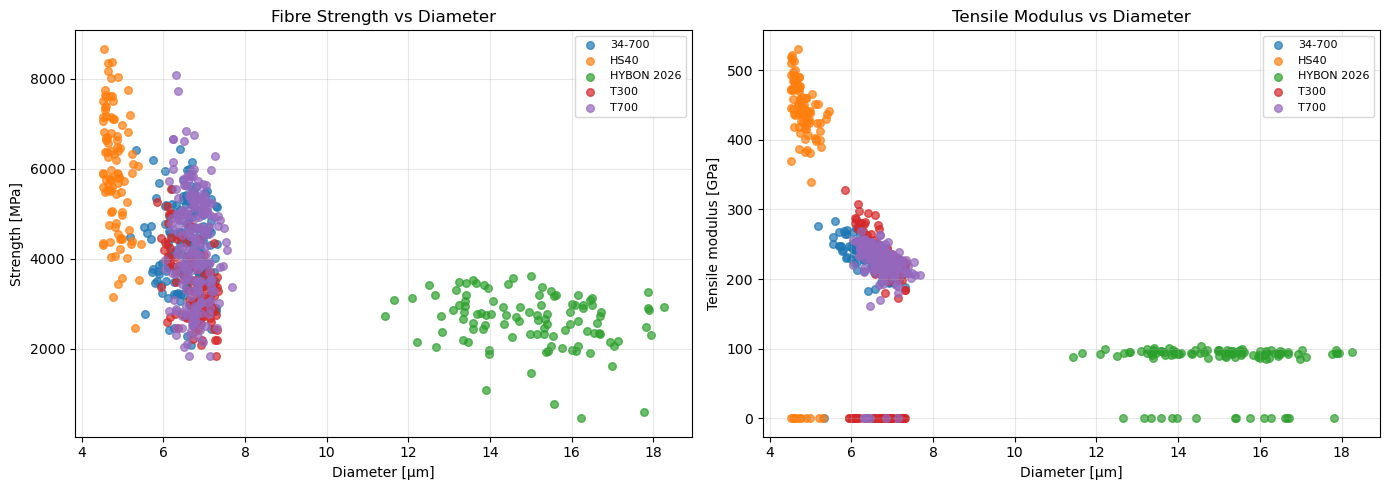

In [3]:
# Compare fibre types: Strength & Tensile Modulus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ft in fibre_types:
    sub = df_all[df_all['Fibre Type'] == ft]
    axes[0].scatter(sub['Diameter [um]'], sub['Strength [MPa]'], label=ft, alpha=0.7, s=30)
    axes[1].scatter(sub['Diameter [um]'], sub['Tensile modulus [GPa]'], label=ft, alpha=0.7, s=30)

axes[0].set(xlabel='Diameter [µm]', ylabel='Strength [MPa]', title='Fibre Strength vs Diameter')
axes[1].set(xlabel='Diameter [µm]', ylabel='Tensile modulus [GPa]', title='Tensile Modulus vs Diameter')
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

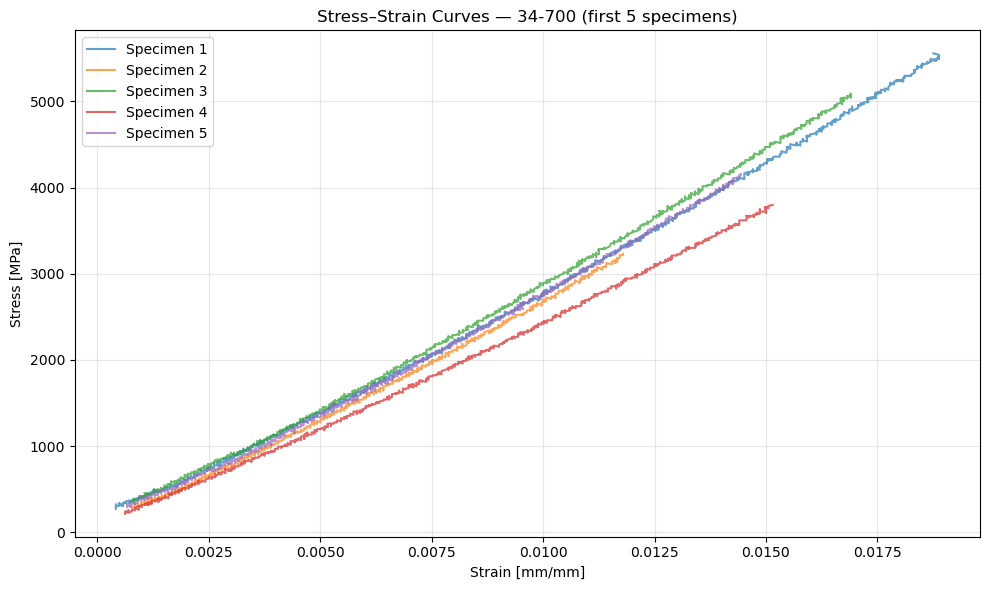

In [4]:
# Load and plot stress-strain curves for one fibre type
ft_example = fibre_types[0]
ss_file = list((GLASS_FIBRE / ft_example).glob('*stress_strain.dat'))[0]
df_ss = pd.read_csv(ss_file, skipinitialspace=True)
# First column is empty due to leading comma — drop it
df_ss = df_ss.iloc[:, 1:]
df_ss.columns = [c.strip() for c in df_ss.columns]

fig, ax = plt.subplots(figsize=(10, 6))
for idx in df_ss['Specimen Index'].unique()[:5]:
    sub = df_ss[df_ss['Specimen Index'] == idx]
    ax.plot(sub['Strain [mm/mm]'], sub['Stress [MPa]'], label=f'Specimen {int(idx)}', alpha=0.7)

ax.set(xlabel='Strain [mm/mm]', ylabel='Stress [MPa]',
       title=f'Stress–Strain Curves — {ft_example} (first 5 specimens)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2 - Inspect the Tomography Image Dataset

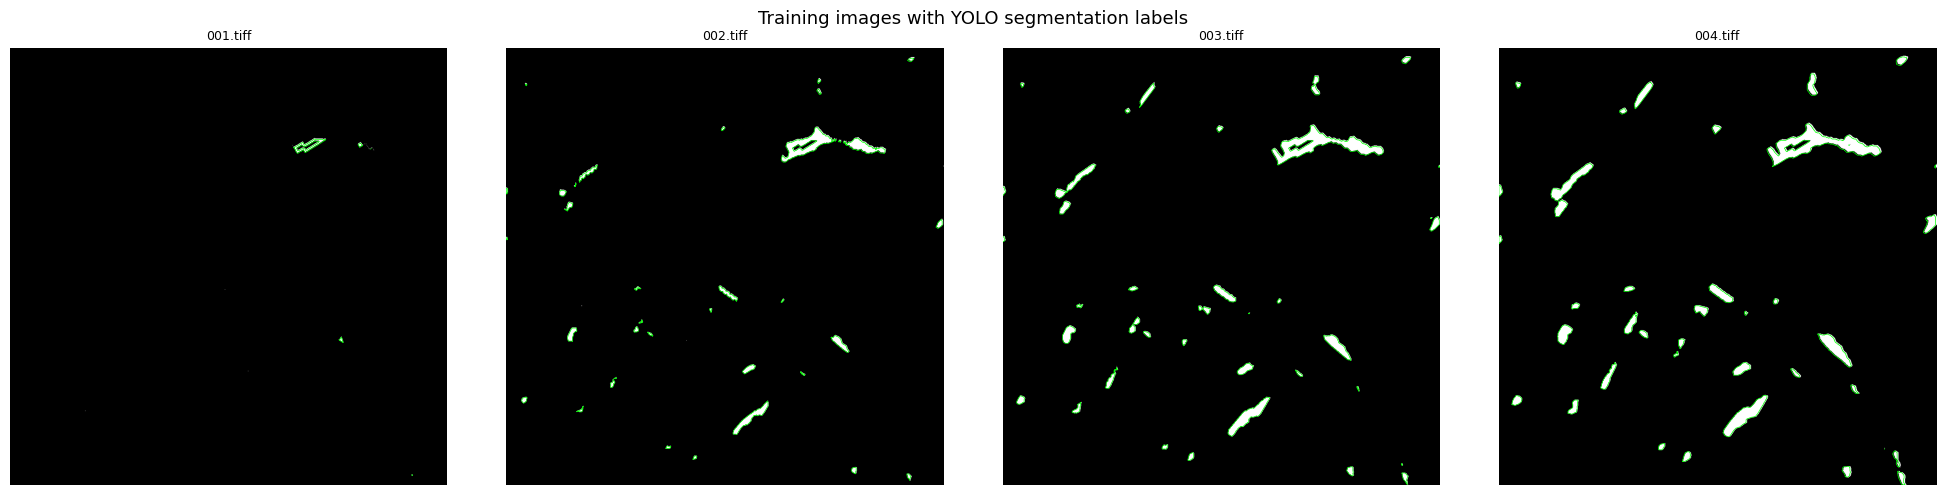

In [5]:
# Show a few training images with their YOLO labels overlaid
train_images = sorted(TRAIN_DIR.glob('*.tiff'))[:4]

fig, axes = plt.subplots(1, len(train_images), figsize=(5 * len(train_images), 5))
if len(train_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, train_images):
    img = io.imread(img_path)
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))  # CHW → HWC
    ax.imshow(img, cmap='gray')

    # Overlay YOLO polygon labels if present
    label_path = img_path.with_suffix('.txt')
    if label_path.exists():
        H = img.shape[0] if img.ndim == 2 else img.shape[0]
        W = img.shape[1] if img.ndim == 2 else img.shape[1]
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                coords = np.array([float(v) for v in parts[1:]]).reshape(-1, 2)
                coords[:, 0] *= W
                coords[:, 1] *= H
                poly = plt.Polygon(coords, fill=False, edgecolor='lime', linewidth=0.5)
                ax.add_patch(poly)

    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

plt.suptitle('Training images with YOLO segmentation labels', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3 - Dataset YAML Configuration

In [6]:
import yaml

# ── Detection config ───────────────────────────────────────────
det_yaml = {
    'path': str(DATA_DIR.resolve()),
    'train': 'train',
    'val':   'val',
    'names': {0: 'fiber'},
}

det_yaml_path = PROJECT_ROOT / 'glass-fibre-detect.yaml'
with open(det_yaml_path, 'w') as f:
    yaml.dump(det_yaml, f, default_flow_style=False)

# ── Segmentation config (same data, YOLO uses polygon labels) ─
seg_yaml_path = PROJECT_ROOT / 'glass-fibre-segment.yaml'
with open(seg_yaml_path, 'w') as f:
    yaml.dump(det_yaml, f, default_flow_style=False)   # same content; the task flag decides detect vs segment

print('Detection YAML  :', det_yaml_path)
print('Segmentation YAML:', seg_yaml_path)
print()
print(yaml.dump(det_yaml, default_flow_style=False))

Detection YAML  : glass-fibre-detect.yaml
Segmentation YAML: glass-fibre-segment.yaml

names:
  0: fiber
path: /home/jovyan/mltomo/ai-tomo/glass-fibres
train: train
val: val



---
## 4(a) - YOLO Object Detection (bounding boxes)

Uses `yolo11n.pt` (a detection-only pretrained model).  
YOLO automatically converts polygon labels to bounding boxes when the task is `detect`.

In [7]:
# Load the detection model
det_model = YOLO('yolo11n.pt')   # pretrained COCO detection weights
print(det_model.info())

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients


(181, 2624080, 0, 0.0)


In [8]:
# ── Train detection ────────────────────────────────────────────
#   Adjust epochs, imgsz, batch as needed.
#   Set device='cpu' if no GPU is available.

det_results = det_model.train(
    data   = str(det_yaml_path),
    epochs = 30,
    imgsz  = 640,
    batch  = 16,
    name   = 'glass-fibre-detect',
    project = 'runs',
    patience = 10,
    pretrained = True,
    verbose = True,
)

New https://pypi.org/project/ultralytics/8.4.168 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=glass-fibre-detect.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=glass-fibre-detect4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=runs, rect=False, resume=False

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.4it/s 0.4s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.4it/s 0.4s

                   all         51       4089      0.877      0.558      0.599      0.401


Speed: 0.2ms preprocess, 0.9ms inference, 0.0ms loss, 1.3ms postprocess per image


Results saved to /home/jovyan/mltomo/ai-tomo/runs/glass-fibre-detect4


In [9]:
# ── Evaluate detection on the validation set ───────────────────
det_metrics = det_model.val(data=str(det_yaml_path))

print(f"mAP@50     : {det_metrics.box.map50:.4f}")
print(f"mAP@50-95  : {det_metrics.box.map:.4f}")
print(f"Precision  : {det_metrics.box.mp:.4f}")
print(f"Recall     : {det_metrics.box.mr:.4f}")

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)


YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3381.5±1360.7 MB/s, size: 2935.8 KB)


val: Scanning /home/jovyan/mltomo/ai-tomo/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 16.5Mit/s 0.0s

val: Scanning /home/jovyan/mltomo/ai-tomo/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 93.0Kit/s 0.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.8it/s 5.2s

                   all         51       4089      0.878       0.56      0.601      0.403


Speed: 6.2ms preprocess, 29.2ms inference, 0.0ms loss, 18.0ms postprocess per image


Results saved to /home/jovyan/mltomo/ai-tomo/runs/glass-fibre-detect42


mAP@50     : 0.6012
mAP@50-95  : 0.4026
Precision  : 0.8784
Recall     : 0.5603


0: 640x640 69 fibers, 9.6ms
1: 640x640 68 fibers, 9.6ms
2: 640x640 64 fibers, 9.6ms
3: 640x640 63 fibers, 9.6ms


Speed: 3.0ms preprocess, 9.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


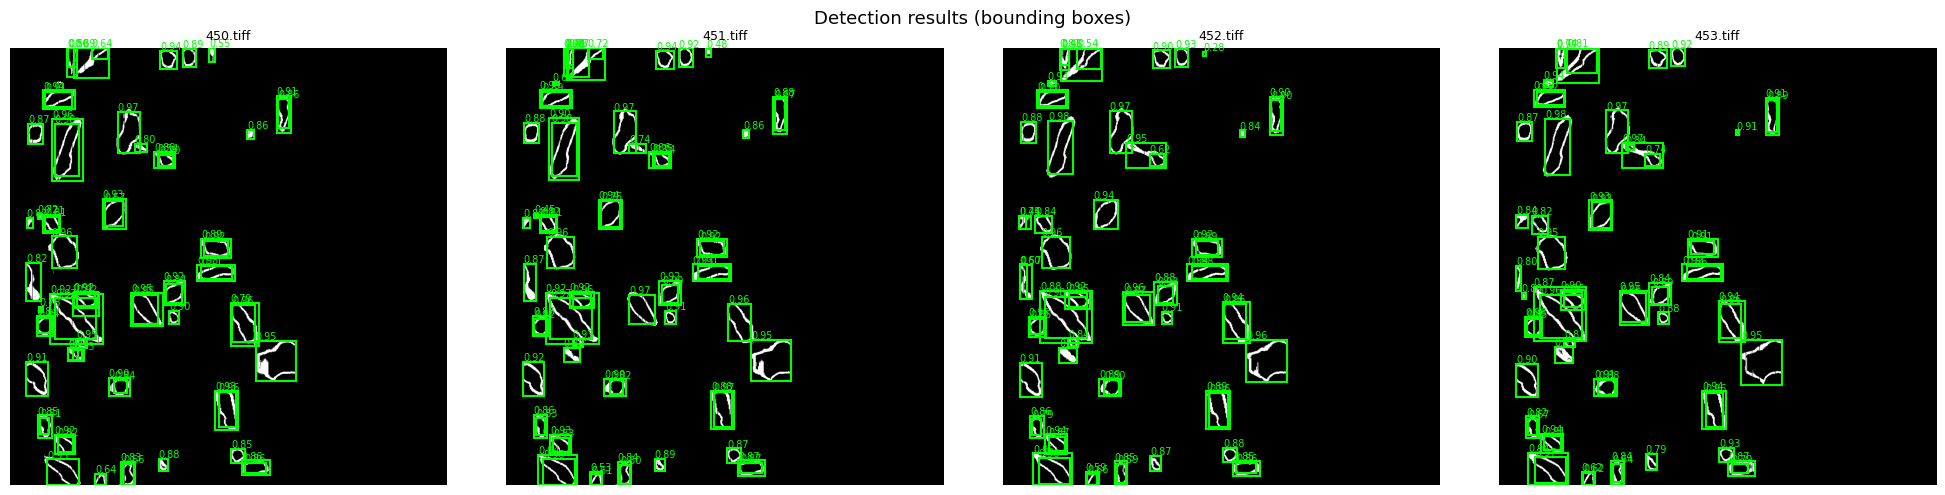

In [10]:
# ── Run detection on sample images ─────────────────────────────
sample_images = sorted(VAL_DIR.glob('*.tiff'))[:4]

det_preds = det_model.predict(
    source = [str(p) for p in sample_images],
    conf   = 0.25,
    save   = False,
)

fig, axes = plt.subplots(1, len(sample_images), figsize=(5 * len(sample_images), 5))
if len(sample_images) == 1:
    axes = [axes]

for ax, result in zip(axes, det_preds):
    img = result.orig_img
    if img.ndim == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img, cmap='gray')

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().item()
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 fill=False, edgecolor='lime', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f'{conf:.2f}', color='lime', fontsize=7)

    ax.set_title(Path(result.path).name, fontsize=9)
    ax.axis('off')

plt.suptitle('Detection results (bounding boxes)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4(b) - YOLO Instance Segmentation (pixel masks)

Uses `yolo11n-seg.pt` (a segmentation pretrained model).  
The polygon labels in the dataset are used directly as segmentation targets.

In [11]:
# Load the segmentation model
seg_model = YOLO('yolo11n-seg.pt')   # pretrained COCO segmentation weights
print(seg_model.info())

YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients


(203, 2876848, 0, 0.0)


In [12]:
# ── Train segmentation ─────────────────────────────────────────
seg_results = seg_model.train(
    data   = str(seg_yaml_path),
    epochs = 30,
    imgsz  = 640,
    batch  = 16,
    name   = 'glass-fibre-segment',
    project = 'runs',
    patience = 10,
    pretrained = True,
    verbose = True,
)

New https://pypi.org/project/ultralytics/8.4.168 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=glass-fibre-segment.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=glass-fibre-segment4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=runs, rect=False, resume

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s

                   all         51       4089      0.883      0.575      0.623      0.402      0.688      0.449       0.42      0.171


Speed: 0.2ms preprocess, 1.5ms inference, 0.0ms loss, 1.5ms postprocess per image


Results saved to /home/jovyan/mltomo/ai-tomo/runs/glass-fibre-segment4


In [13]:
# ── Evaluate segmentation on the validation set ────────────────
seg_metrics = seg_model.val(data=str(seg_yaml_path))

print('=== Box metrics ===')
print(f"  mAP@50     : {seg_metrics.box.map50:.4f}")
print(f"  mAP@50-95  : {seg_metrics.box.map:.4f}")
print()
print('=== Mask metrics ===')
print(f"  mAP@50     : {seg_metrics.seg.map50:.4f}")
print(f"  mAP@50-95  : {seg_metrics.seg.map:.4f}")

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10822MiB)


YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 924.4±342.3 MB/s, size: 2935.8 KB)


val: Scanning /home/jovyan/mltomo/ai-tomo/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 13.4Mit/s 0.0s

val: Scanning /home/jovyan/mltomo/ai-tomo/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 43.7Kit/s 0.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.9it/s 4.6s

                   all         51       4089      0.884      0.574      0.622      0.403      0.678      0.436      0.406      0.166


Speed: 8.2ms preprocess, 4.7ms inference, 0.0ms loss, 6.3ms postprocess per image


Results saved to /home/jovyan/mltomo/ai-tomo/runs/glass-fibre-segment42


=== Box metrics ===
  mAP@50     : 0.6219
  mAP@50-95  : 0.4029

=== Mask metrics ===
  mAP@50     : 0.4059
  mAP@50-95  : 0.1657


0: 640x640 72 fibers, 13.4ms
1: 640x640 68 fibers, 13.4ms
2: 640x640 70 fibers, 13.4ms
3: 640x640 71 fibers, 13.4ms


Speed: 4.5ms preprocess, 13.4ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)


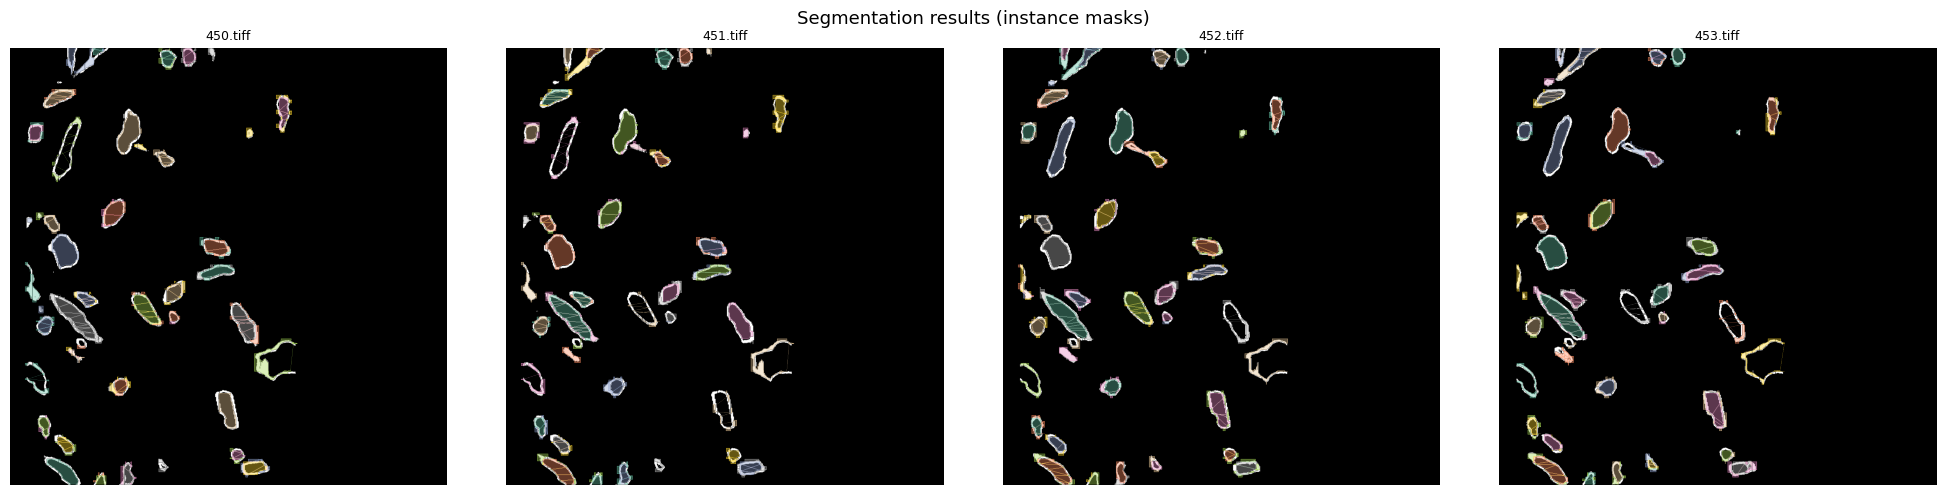

In [14]:
# ── Run segmentation on sample images ──────────────────────────
seg_preds = seg_model.predict(
    source = [str(p) for p in sample_images],
    conf   = 0.25,
    save   = False,
)

fig, axes = plt.subplots(1, len(sample_images), figsize=(5 * len(sample_images), 5))
if len(sample_images) == 1:
    axes = [axes]

colors = plt.cm.Set2(np.linspace(0, 1, 8))

for ax, result in zip(axes, seg_preds):
    img = result.orig_img
    if img.ndim == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img, cmap='gray')

    # Overlay masks
    if result.masks is not None:
        overlay = np.zeros((*img.shape[:2], 4), dtype=np.float32)
        for i, mask_xy in enumerate(result.masks.xy):
            contour = np.array(mask_xy, dtype=np.int32).reshape((-1, 1, 2))
            c = colors[i % len(colors)]
            tmp = np.zeros((*img.shape[:2], 4), dtype=np.float32)
            cv2.drawContours(tmp, [contour], -1, (*c[:3], 0.4), cv2.FILLED)
            cv2.drawContours(tmp, [contour], -1, (*c[:3], 1.0), 1)
            overlay = np.maximum(overlay, tmp)
        ax.imshow(overlay)

    ax.set_title(Path(result.path).name, fontsize=9)
    ax.axis('off')

plt.suptitle('Segmentation results (instance masks)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 - Compare Detection vs Segmentation

image 1/1 /home/jovyan/mltomo/ai-tomo/glass-fibres/val/450.tiff: 640x640 69 fibers, 9.1ms


Speed: 3.4ms preprocess, 9.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


image 1/1 /home/jovyan/mltomo/ai-tomo/glass-fibres/val/450.tiff: 640x640 72 fibers, 9.5ms


Speed: 3.9ms preprocess, 9.5ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 640)


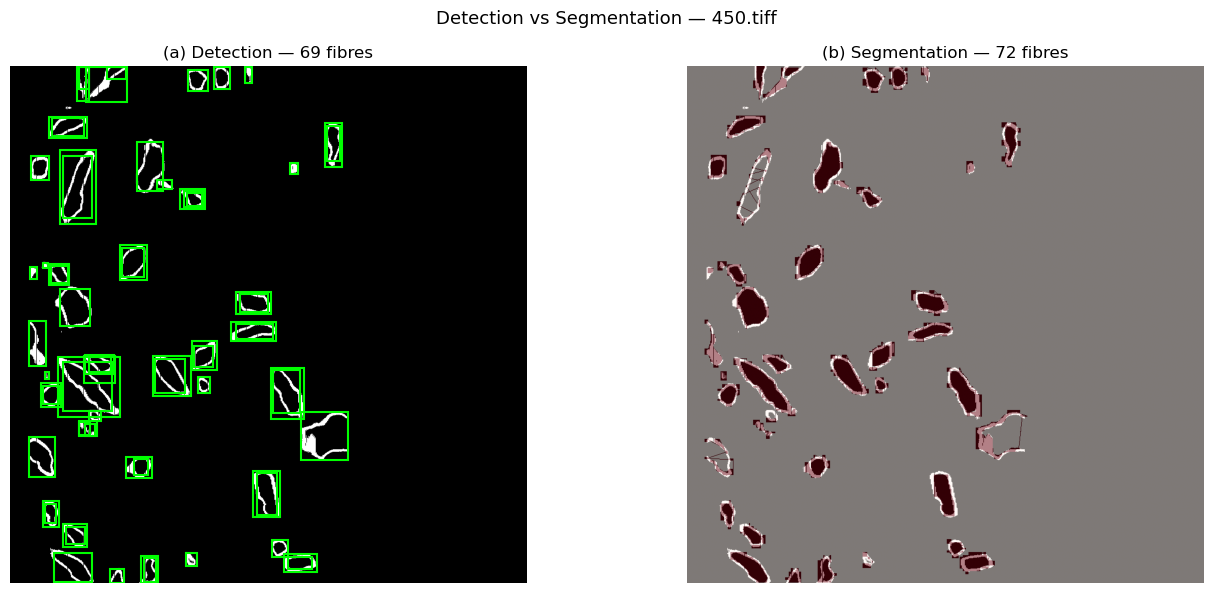

In [15]:
# Side-by-side comparison on a single image
test_img = sorted(VAL_DIR.glob('*.tiff'))[0]

det_r = det_model.predict(str(test_img), conf=0.25, save=False)[0]
seg_r = seg_model.predict(str(test_img), conf=0.25, save=False)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Detection ──
img_det = det_r.orig_img.copy()
if img_det.ndim == 3 and img_det.shape[2] == 3:
    img_det = cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB)
ax1.imshow(img_det, cmap='gray')
if det_r.boxes is not None:
    for box in det_r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, edgecolor='lime', linewidth=1.5)
        ax1.add_patch(rect)
ax1.set_title(f'(a) Detection — {len(det_r.boxes) if det_r.boxes is not None else 0} fibres')
ax1.axis('off')

# ── Segmentation ──
img_seg = seg_r.orig_img.copy()
if img_seg.ndim == 3 and img_seg.shape[2] == 3:
    img_seg = cv2.cvtColor(img_seg, cv2.COLOR_BGR2RGB)
ax2.imshow(img_seg, cmap='gray')
if seg_r.masks is not None:
    mask_combined = np.zeros(img_seg.shape[:2], dtype=np.float32)
    for mask_xy in seg_r.masks.xy:
        contour = np.array(mask_xy, dtype=np.int32).reshape((-1, 1, 2))
        cv2.drawContours(mask_combined, [contour], -1, 1.0, cv2.FILLED)
    ax2.imshow(mask_combined, cmap='Reds', alpha=0.5)
n_masks = len(seg_r.masks.xy) if seg_r.masks is not None else 0
ax2.set_title(f'(b) Segmentation — {n_masks} fibres')
ax2.axis('off')

plt.suptitle(f'Detection vs Segmentation — {test_img.name}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 - Export & Reload Best Weights

After training, the best weights are saved under `runs/`.  
Use the cells below to reload a trained model for inference.

In [16]:
# ── Reload detection model ─────────────────────────────────────
# det_best = YOLO('runs/glass-fibre-detect/weights/best.pt')

# ── Reload segmentation model ──────────────────────────────────
# seg_best = YOLO('runs/glass-fibre-segment/weights/best.pt')

# ── Or use the previously trained segmentation model ───────────
# seg_prev = YOLO('runs/segment/train14/weights/best.pt')

print('Uncomment the model you want to reload.')

Uncomment the model you want to reload.


In [17]:
# ── Export to ONNX (optional) ──────────────────────────────────
# det_model.export(format='onnx', imgsz=640)
# seg_model.export(format='onnx', imgsz=640)

print('Uncomment to export models.')

Uncomment to export models.
